In [143]:
import pandas as pd
import numpy as np

In [144]:
df=pd.read_csv("/content/Churn_Modelling.csv")

In [145]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [147]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [148]:
df.duplicated().sum()

np.int64(0)

In [149]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [150]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [151]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

**checking outliers**

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

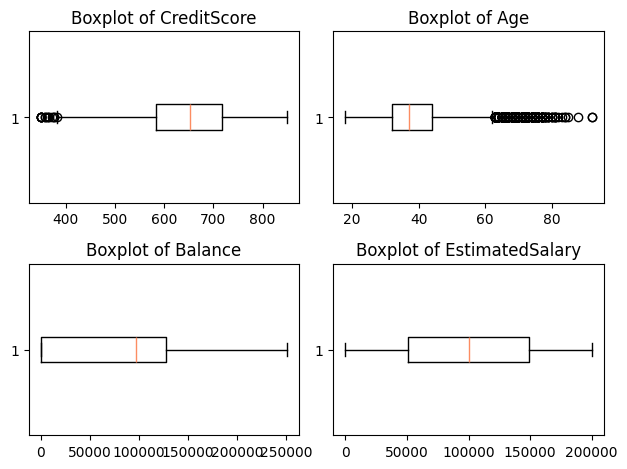

In [153]:
numerical_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# Create box plots for each feature to visually inspect outliers

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[feature], vert=False)
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

Exploratory Data Analysis

The goal of EDA is to better understand the distributions of features, identify trends or patterns, and explore relationships between features and the target variable (Exited)

UNI-Variate Analysis

In [154]:
df['CreditScore'].describe()

,CreditScore
count,10000.000000
mean,650.528800
std,96.653299
min,350.000000
25%,584.000000
50%,652.000000
75%,718.000000
max,850.000000


/tmp/ipykernel_647/1331064389.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(df['CreditScore'], fill=True, palette="Set2")


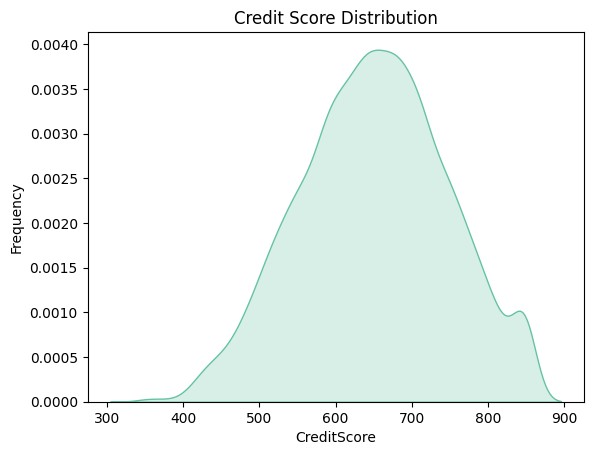

In [155]:
sns.kdeplot(df['CreditScore'], fill=True, palette="Set2")
plt.title('Credit Score Distribution')
plt.xlabel('CreditScore')
plt.ylabel('Frequency')

plt.show()

The distribution of credit scores is slightly skewed to the right, meaning more customers have higher credit scores (closer to 800).


This could indicate that most customers have a good credit history

In [156]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


/tmp/ipykernel_647/230636353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x="Geography",palette="Set2")


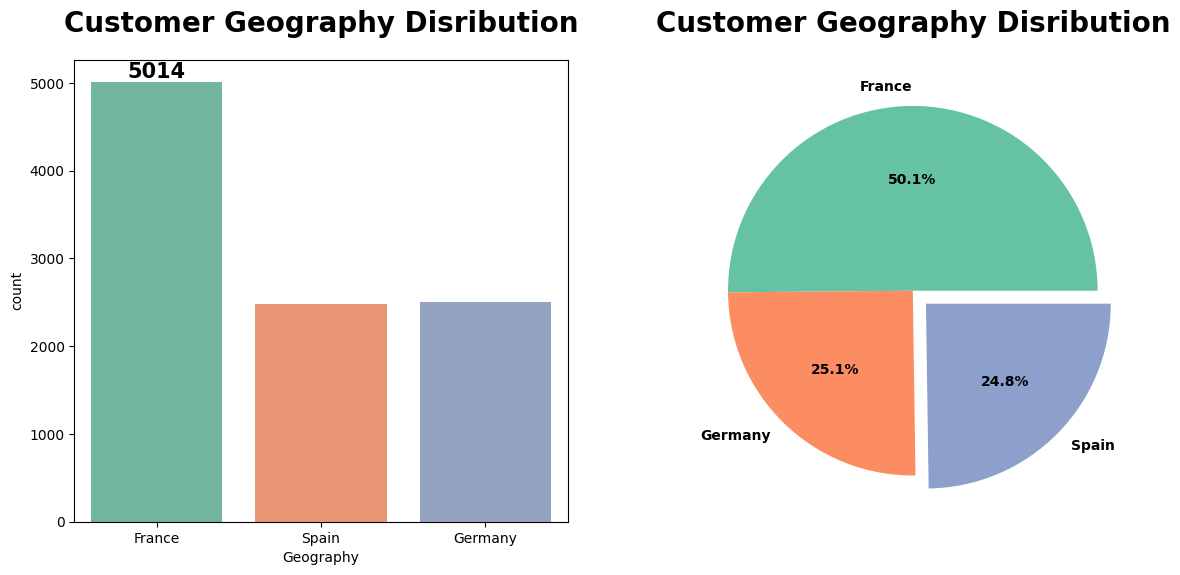

In [157]:
count = df["Geography"].value_counts()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
ax=sns.countplot(data=df, x="Geography",palette="Set2")
ax.bar_label(ax.containers[0],fontweight="black",size=15)
plt.title("Customer Geography Disribution",fontweight="black",size=20,pad=20)

plt.subplot(1,2,2)
plt.pie(count.values, labels=count.index, autopct="%1.1f%%",colors=sns.set_palette("Set2"),
        textprops={"fontweight":"black"},explode=[0, 0,0.1])
plt.title("Customer Geography Disribution",fontweight="black",size=20,pad=20)
plt.show()

In [158]:
df["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


/tmp/ipykernel_647/749704535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x="Gender",palette="Set2")


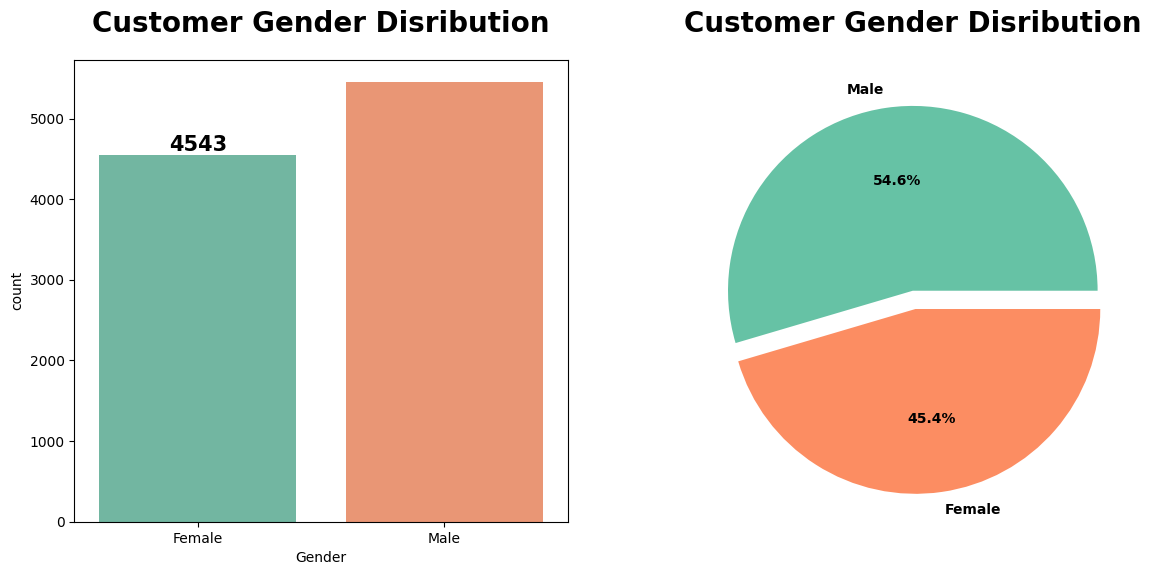

In [159]:
count = df["Gender"].value_counts()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
ax=sns.countplot(data=df, x="Gender",palette="Set2")
ax.bar_label(ax.containers[0],fontweight="black",size=15)
plt.title("Customer Gender Disribution",fontweight="black",size=20,pad=20)

plt.subplot(1,2,2)
plt.pie(count.values, labels=count.index, autopct="%1.1f%%",colors=sns.set_palette("Set2"),
        textprops={"fontweight":"black"},explode=[0, 0.1])
plt.title("Customer Gender Disribution",fontweight="black",size=20,pad=20)
plt.show()

In [160]:
df['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


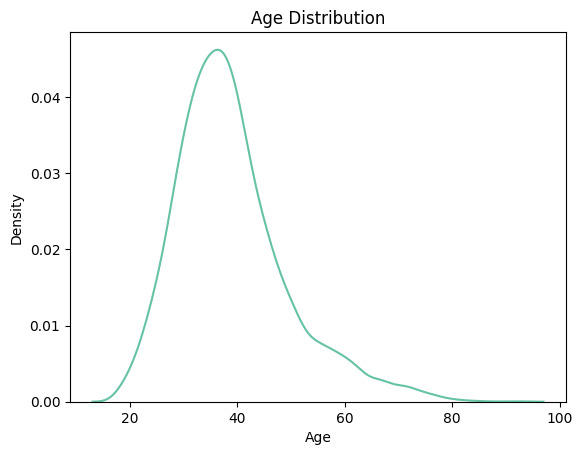

In [161]:
sns.kdeplot(df["Age"])
plt.title("Age Distribution")
plt.show()

/tmp/ipykernel_647/928400458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"])


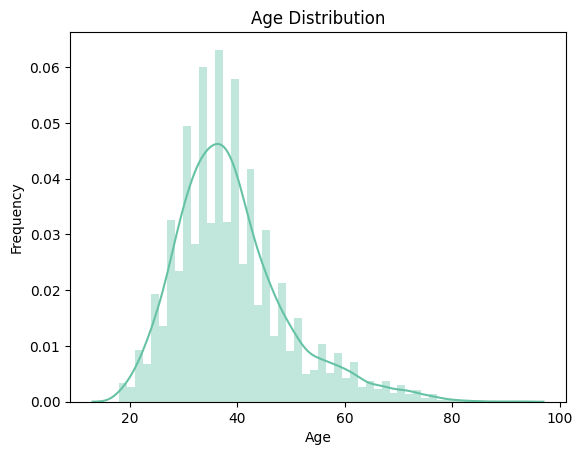

In [162]:
sns.distplot(df["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution is concentrated around 30–50 years, with fewer customers in the older age range.

This suggests that most customers are middle-aged, which might be relevant depending on the bank’s target demographic.

In [163]:
df["Tenure"].value_counts()

,count
Tenure,
2,1048
1,1035
7,1028
8,1025
5,1012
3,1009
4,989
9,984
6,967


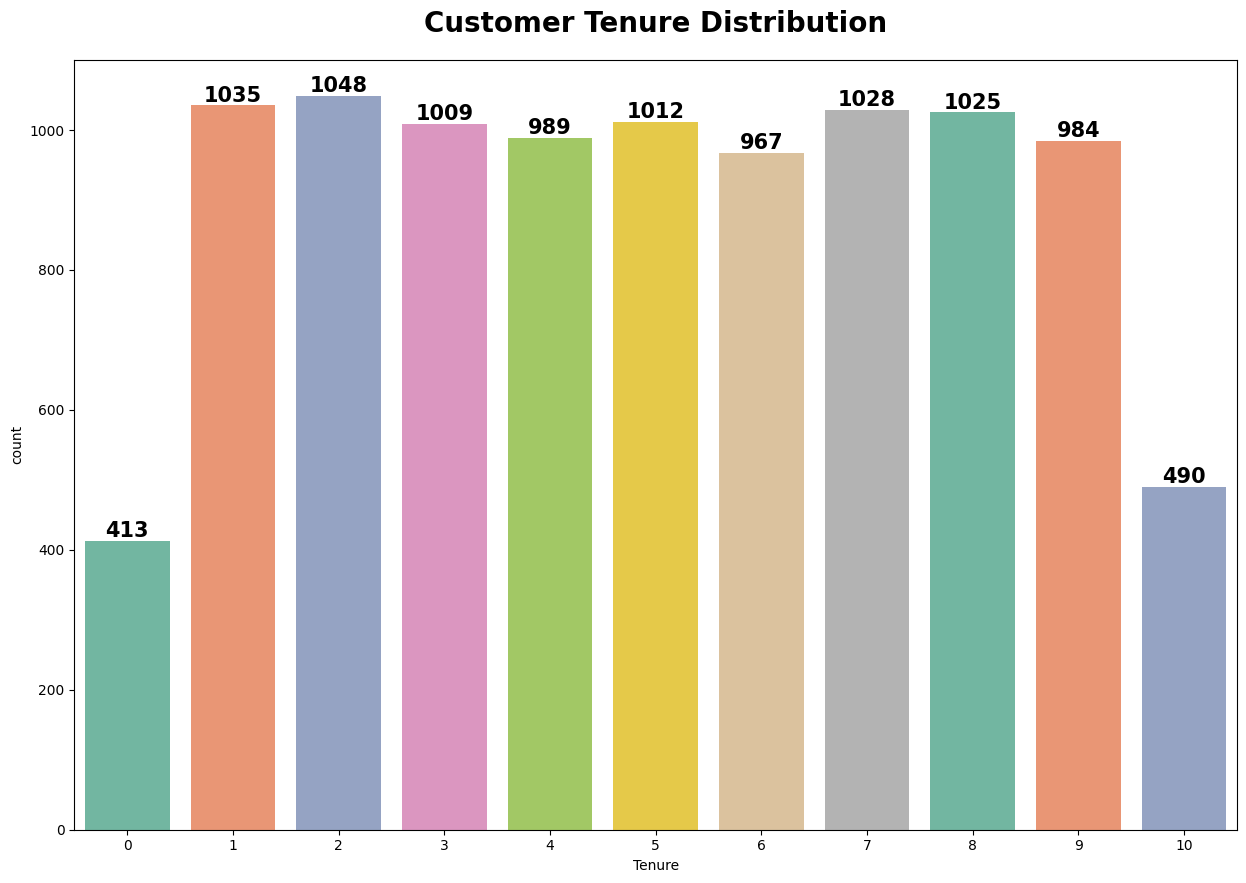

In [164]:
plt.figure(figsize=(15,10))

ax=sns.countplot(data=df, x="Tenure", hue="Tenure", palette="Set2", legend=False)
for container in ax.containers:
    ax.bar_label(container,fontweight="black",size=15)
plt.title("Customer Tenure Distribution",fontweight="black",size=20,pad=20)

plt.show()

The uniform distribution suggests that the bank has a balanced customer base across different tenure lengths.

/tmp/ipykernel_647/312011609.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(df['Balance'], fill=True, palette="Set2")


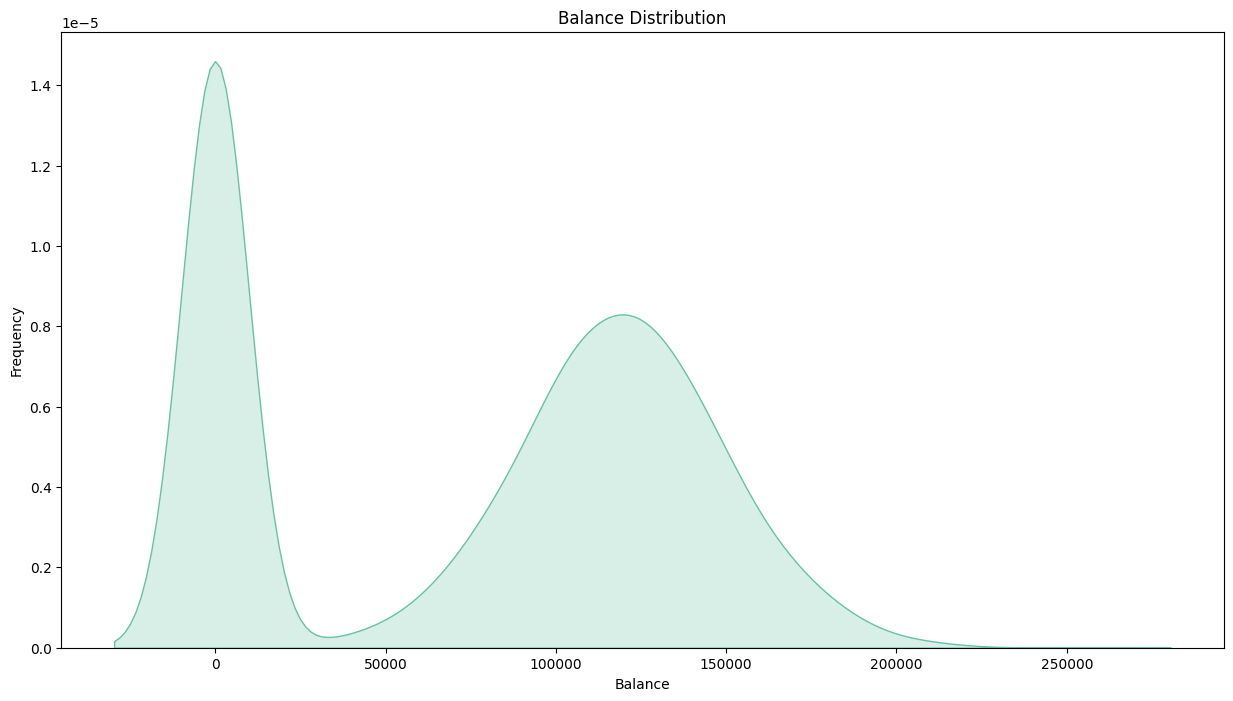

In [165]:
plt.figure(figsize=(15, 8))

sns.kdeplot(df['Balance'], fill=True, palette="Set2")
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')

plt.show()

A bimodal distribution in the Balance column suggests two distinct customer segments:

Low-balance customers who may be more likely to churn.

High-balance customers who are likely more engaged and loyal.


In [166]:
df["NumOfProducts"].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


/tmp/ipykernel_647/3678706725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x="NumOfProducts",palette="Set2")


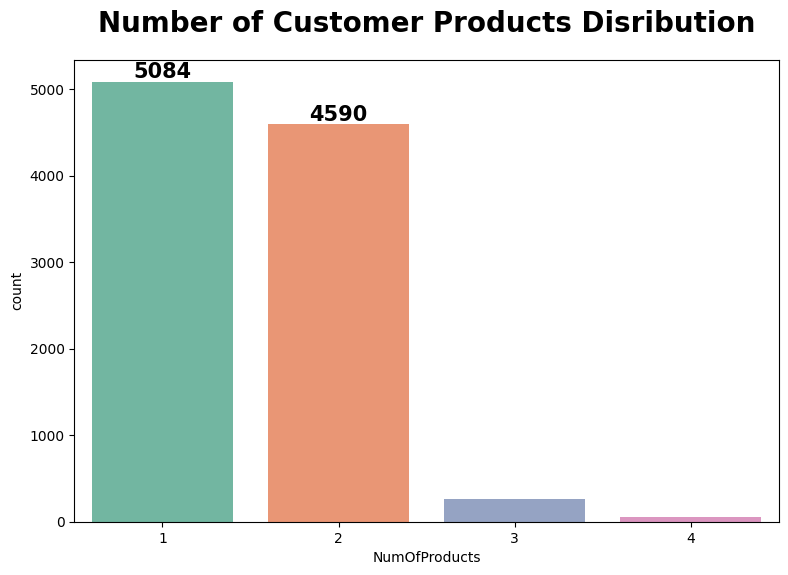

In [167]:
count = df["NumOfProducts"].value_counts()

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
ax=sns.countplot(data=df, x="NumOfProducts",palette="Set2")
ax.bar_label(ax.containers[0],fontweight="black",size=15)
ax.bar_label(ax.containers[1],fontweight="black",size=15)
plt.title("Number of Customer Products Disribution",fontweight="black",size=20,pad=20)

plt.show()

In [168]:
df["HasCrCard"].value_counts()

,count
HasCrCard,
1,7055
0,2945


/tmp/ipykernel_647/3963469768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x="HasCrCard",palette="Set2")


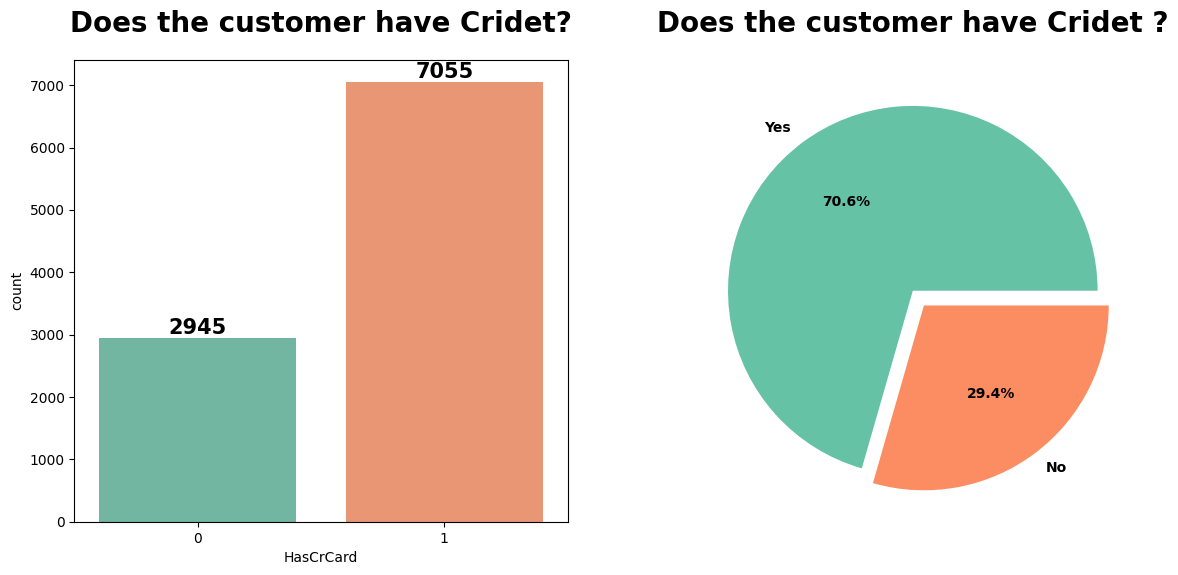

In [169]:
count = df["HasCrCard"].value_counts()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
ax=sns.countplot(data=df, x="HasCrCard",palette="Set2")
ax.bar_label(ax.containers[0],fontweight="black",size=15)
ax.bar_label(ax.containers[1],fontweight="black",size=15)
plt.title("Does the customer have Cridet?",fontweight="black",size=20,pad=20)

plt.subplot(1,2,2)
plt.pie(count.values, labels=['Yes', 'No'], autopct="%1.1f%%",colors=sns.set_palette("Set2"),
        textprops={"fontweight":"black"},explode=[0, 0.1])
plt.title("Does the customer have Cridet ?",fontweight="black",size=20,pad=20)
plt.show()

In [170]:
df['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


/tmp/ipykernel_647/446213748.py:20: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  ax.legend(handles=handles, labels=mapped_labels)
/tmp/ipykernel_647/446213748.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=handles, labels=mapped_labels)


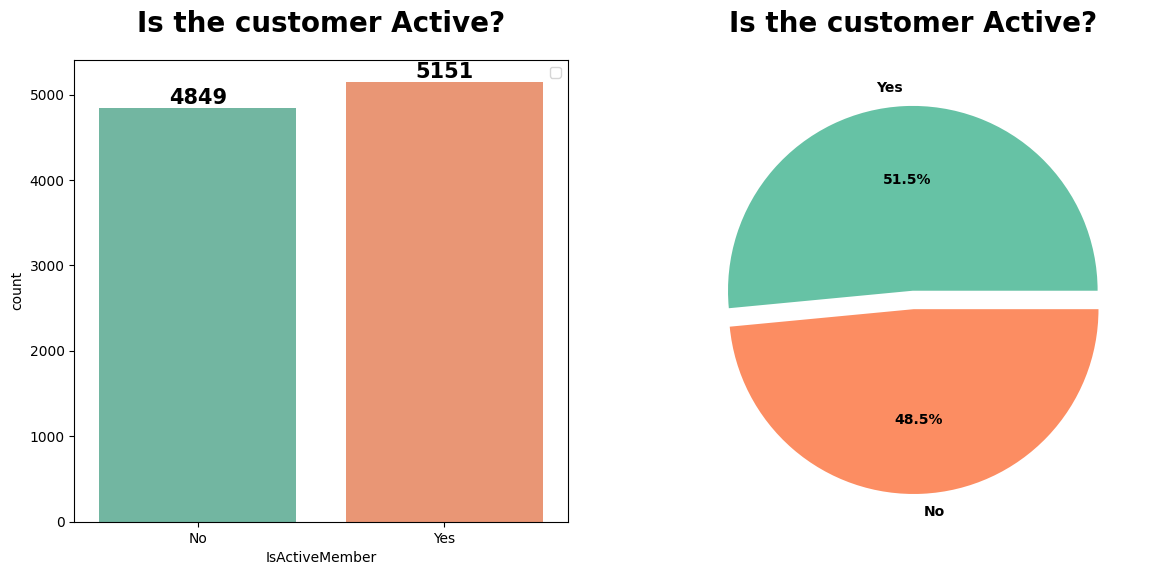

In [171]:
count = df["IsActiveMember"].value_counts()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
ax=sns.countplot(data=df, x="IsActiveMember", hue="IsActiveMember", palette="Set2", legend=False)

# Label all bars correctly
for container in ax.containers:
    ax.bar_label(container, fontweight="black", size=15)

plt.title("Is the customer Active?",fontweight="black",size=20,pad=20)

# Set custom x-axis tick labels to be descriptive
plt.xticks([0, 1], ['No', 'Yes'])

# Manually update legend labels to be descriptive
handles, labels = ax.get_legend_handles_labels()
# Assuming '0' corresponds to 'No' and '1' to 'Yes'
mapped_labels = ['No', 'Yes']
ax.legend(handles=handles, labels=mapped_labels)


plt.subplot(1,2,2)
plt.pie(count.values, labels=['Yes', 'No'], autopct="%1.1f%%",colors=sns.set_palette("Set2"),
        textprops={"fontweight":"black"},explode=[0, 0.1])
plt.title("Is the customer Active?",fontweight="black",size=20,pad=20)
plt.show()

In [172]:
df['EstimatedSalary'].describe()

,EstimatedSalary
count,10000.000000
mean,100090.239881
std,57510.492818
min,11.580000
25%,51002.110000
50%,100193.915000
75%,149388.247500
max,199992.480000


/tmp/ipykernel_647/1575628732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(df['EstimatedSalary'], fill=True, palette="Set2")


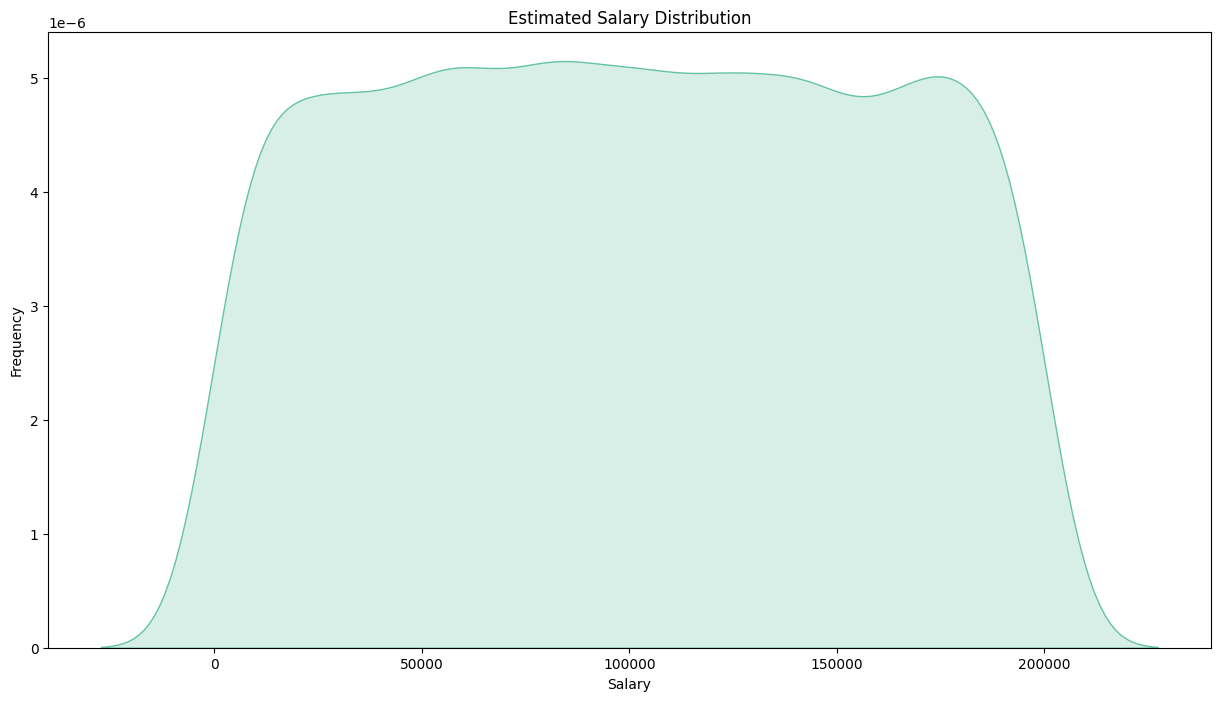

In [173]:
plt.figure(figsize=(15, 8))

sns.kdeplot(df['EstimatedSalary'], fill=True, palette="Set2")
plt.title('Estimated Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')

plt.show()

In [174]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


/tmp/ipykernel_647/1638040995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x="Exited",palette="Set2")


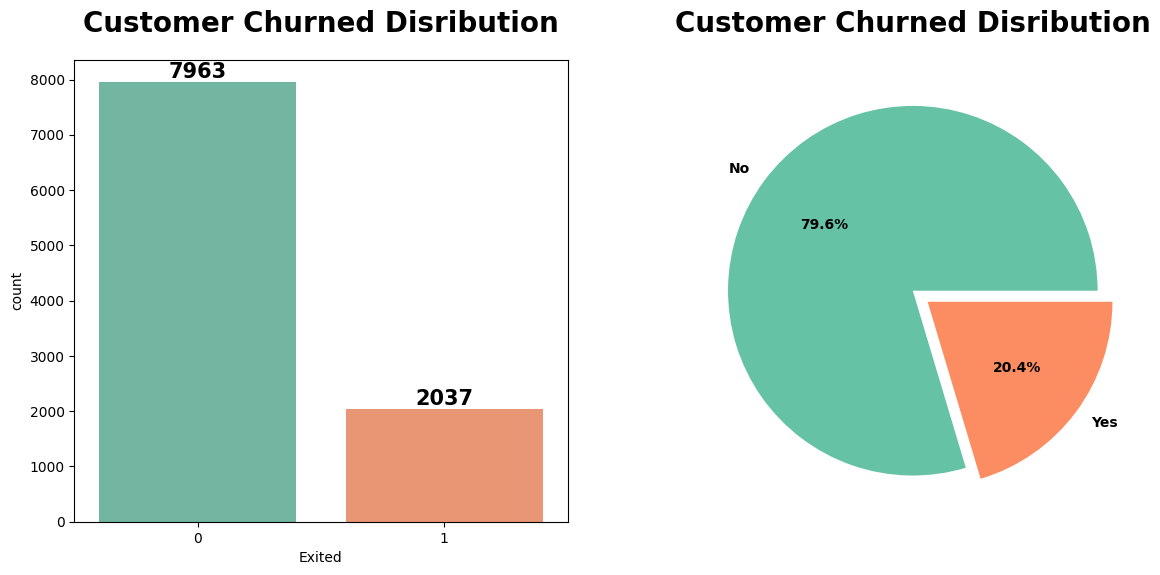

In [175]:
count = df["Exited"].value_counts()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
ax=sns.countplot(data=df, x="Exited",palette="Set2")
ax.bar_label(ax.containers[0],fontweight="black",size=15)
ax.bar_label(ax.containers[1],fontweight="black",size=15)
plt.title("Customer Churned Disribution",fontweight="black",size=20,pad=20)

plt.subplot(1,2,2)
plt.pie(count.values, labels=['No', 'Yes'], autopct="%1.1f%%",colors=sns.set_palette("Set2"),
        textprops={"fontweight":"black"},explode=[0, 0.1])
plt.title("Customer Churned Disribution",fontweight="black",size=20,pad=20)
plt.show()

BI-Variate Analysis

Numerical Features vs. Churn (Exited)

In [176]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [177]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


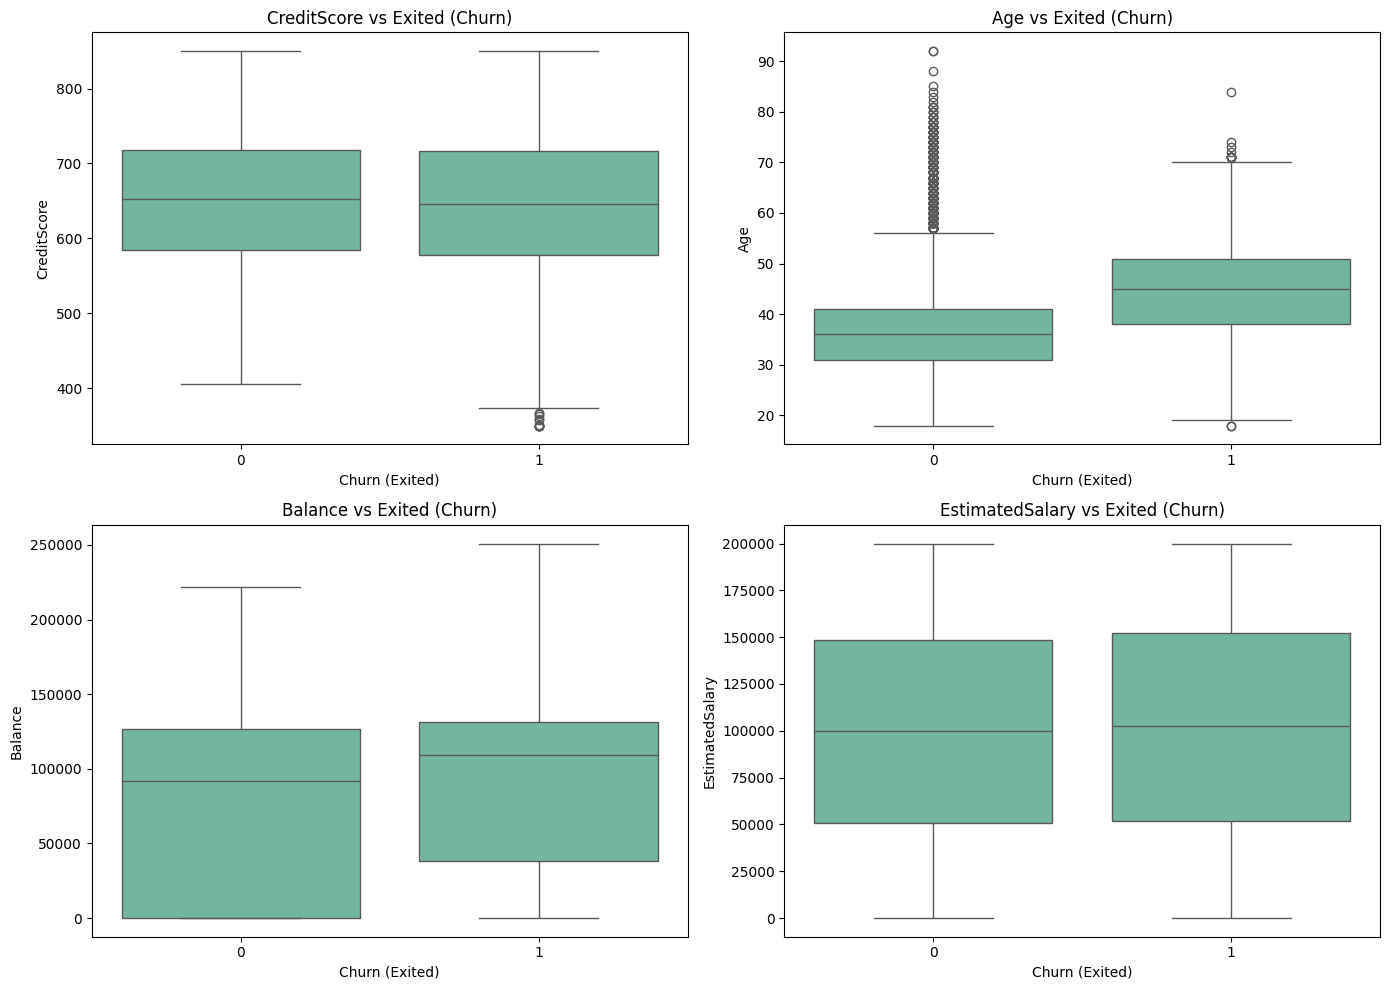

In [178]:
numerical_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# Plotting the relationship between each numerical feature and churn (Exited)
plt.figure(figsize=(14, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Exited', y=feature, data=df)
    plt.title(f'{feature} vs Exited (Churn)')
    plt.xlabel('Churn (Exited)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

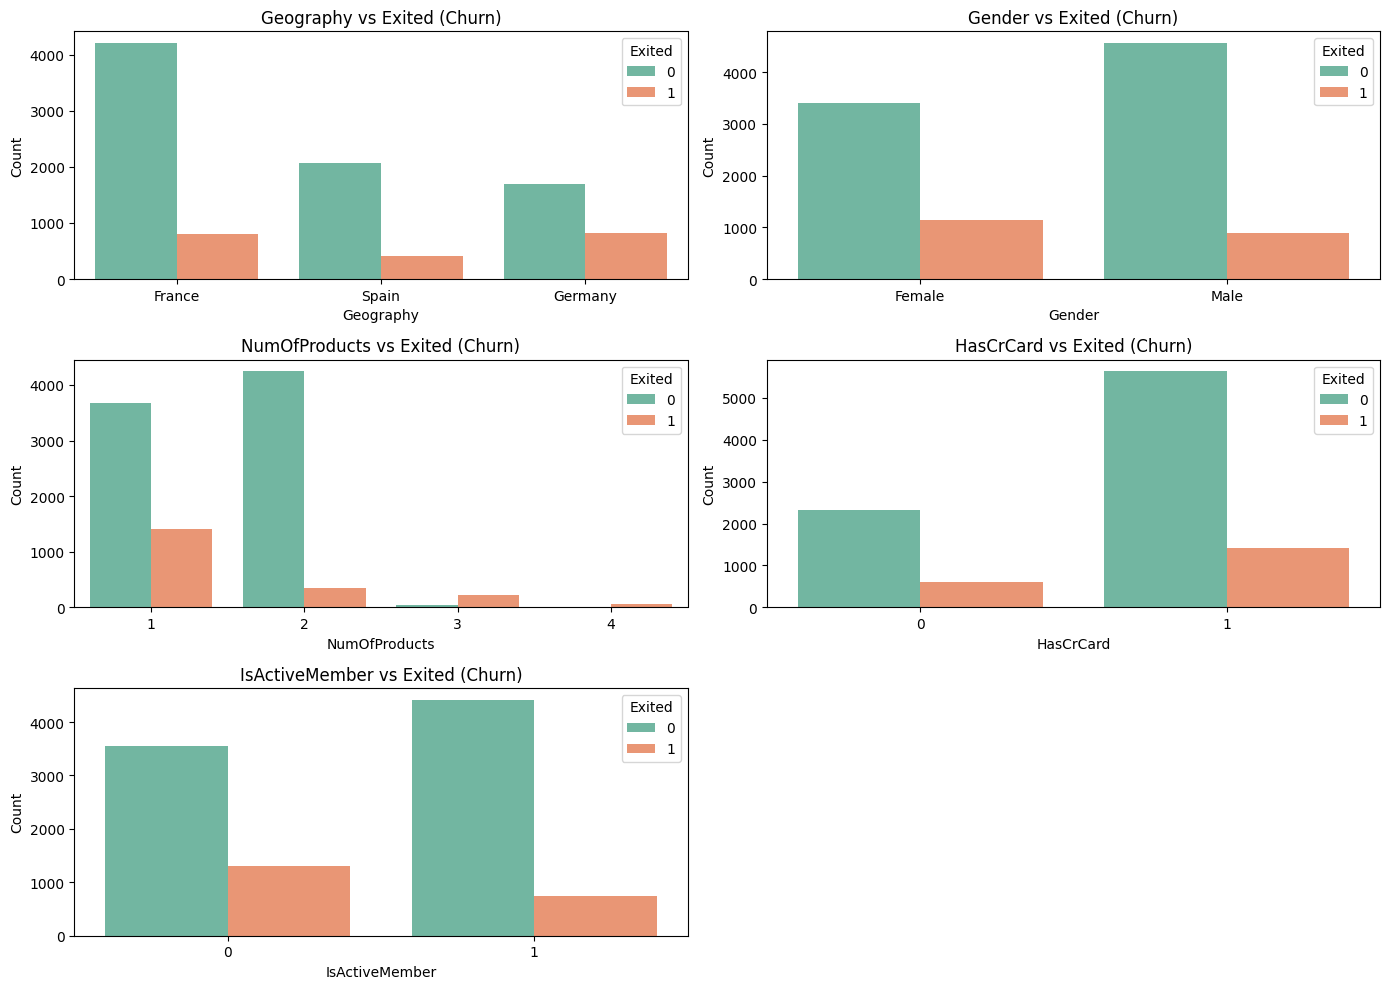

In [179]:
categorical_features = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Plotting the relationship between each categorical feature and churn (Exited)
plt.figure(figsize=(14, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=feature, hue='Exited', data=df)
    plt.title(f'{feature} vs Exited (Churn)')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

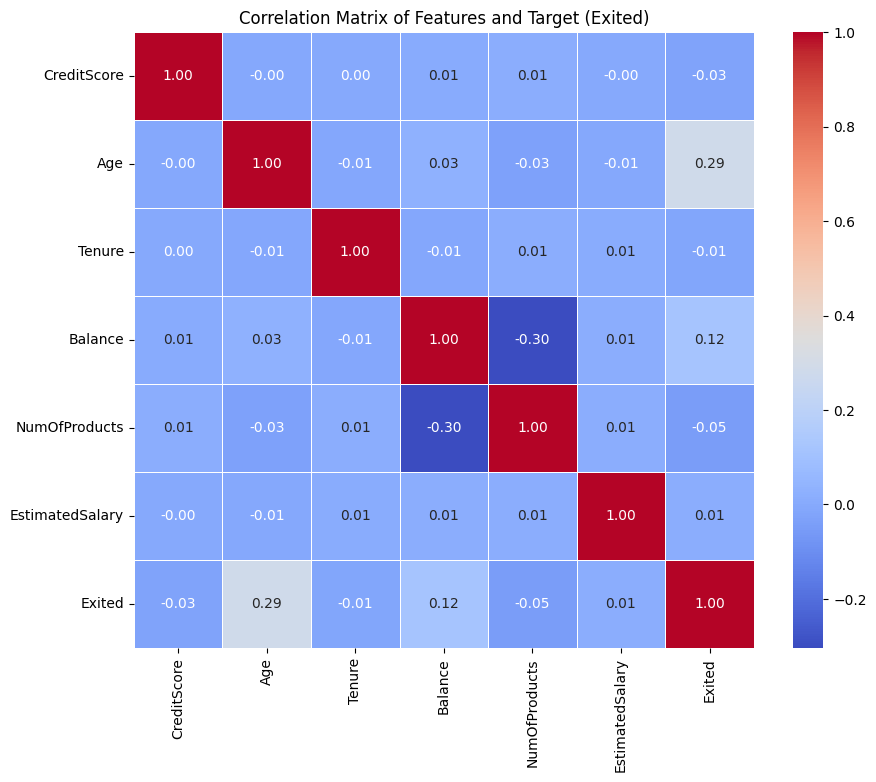

In [180]:
numerical_features_with_target = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']

# Compute the correlation matrix
correlation_matrix = df[numerical_features_with_target].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features and Target (Exited)')
plt.show()

Data Preprocessing

Drop Unneeded Columns

In [181]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [182]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [185]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [186]:
X.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [187]:
y


,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


Data Encoding

To apply encoding to categorical columns in your dataset, the type of encoding will depend on whether the categorical variables are nominal (unordered) or ordinal (ordered)

In [188]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=False)

In [189]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False


Data Scalling

In [190]:
from sklearn.preprocessing import StandardScaler

In [191]:
scaler = StandardScaler()

# Apply scaling to numerical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [192]:
from sklearn.model_selection import train_test_split

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [194]:
X_train.shape

(8000, 13)

In [195]:
X_test.shape

(2000, 13)

In [196]:
y_train.shape

(8000,)

In [197]:
y_test.shape

(2000,)

In [198]:
from sklearn.linear_model import LogisticRegression

In [199]:
lr = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)

# Train the model
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [200]:
lr.score(X_train, y_train)

0.81125

In [201]:
# Make predictions on the test set
y_pred = lr.predict(X_test)

In [202]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [203]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix

In [204]:
# Get our metrics
lr_acc = accuracy_score(y_test, y_pred)
lr_per = precision_score(y_test, y_pred)
lr_rec = recall_score(y_test, y_pred)
lr_cm = confusion_matrix(y_test, y_pred)

In [205]:
lr_acc

0.811

In [206]:
lr_cm

array([[1543,   64],
       [ 314,   79]])

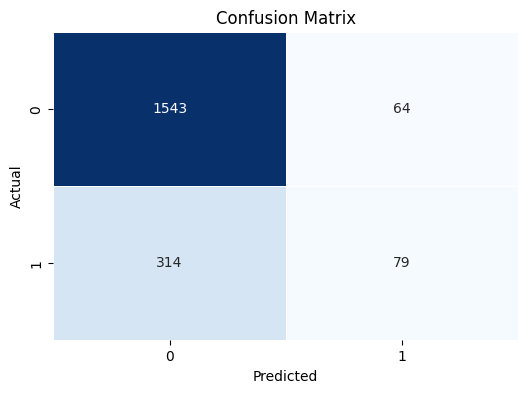

In [207]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic Regression Classification Report

In [329]:
# Make predictions for Logistic Regression
y_pred_lr = lr.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



SVM MOdel

In [209]:
from sklearn.svm import SVC

In [210]:
param_grid = {'kernel': ['linear', 'poly', 'rbf'],
              'C': [0.1, 1, 10]}

svm = SVC()

In [212]:
from sklearn.model_selection import GridSearchCV

In [213]:
# Perform Grid Search with cross-validation
grid_search = GridSearchCV(svm, param_grid, cv=5)
grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'poly', 'rbf']})

In [214]:
best_model = grid_search.best_estimator_
best_model

SVC(C=10)

In [215]:
print(best_model.score(X_train, y_train))

0.881375


In [216]:
print(best_model.score(X_test, y_test))

0.882


In [217]:
y_pred = best_model.predict(X_test)

In [218]:
svc_acc = accuracy_score(y_test, y_pred)
svc_per = precision_score(y_test, y_pred)
svc_rec = recall_score(y_test, y_pred)

### Logistic Regression Classification Report

In [319]:
# Make predictions for Logistic Regression
y_pred_lr = lr.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### K-Neighbors Classifier Classification Report

In [320]:
# Make predictions for K-Neighbors Classifier
y_pred_knn = knn.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1607
           1       0.60      0.41      0.49       393

    accuracy                           0.83      2000
   macro avg       0.73      0.67      0.69      2000
weighted avg       0.81      0.83      0.82      2000



### Decision Tree Classifier Classification Report

In [321]:
# Make predictions for Decision Tree Classifier
y_pred_clf = clf.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.67      0.41      0.51       393

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000



### Random Forest Classifier Classification Report

In [322]:
# Make predictions for Random Forest Classifier
y_pred_rf = RF_classifier.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Bagging Classifier Classification Report

In [323]:
# Make predictions for Bagging Classifier
y_pred_bag = bagged_classifier.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_bag))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.67      0.41      0.51       393

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000



### ExtraTreesClassifier Classification Report

In [324]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_et))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### AdaBoostClassifier Classification Report

In [325]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_ab))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.72      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



### XGBoostClassifier Classification Report

In [326]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1607
           1       0.69      0.53      0.60       393

    accuracy                           0.86      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



### CatBoostClassifier Classification Report

In [327]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_catboost))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.49      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



### LGBMClassifier Classification Report

In [328]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.73      0.51      0.60       393

    accuracy                           0.87      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [317]:
from sklearn.metrics import classification_report

# Get our metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.67      0.41      0.51       393

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000



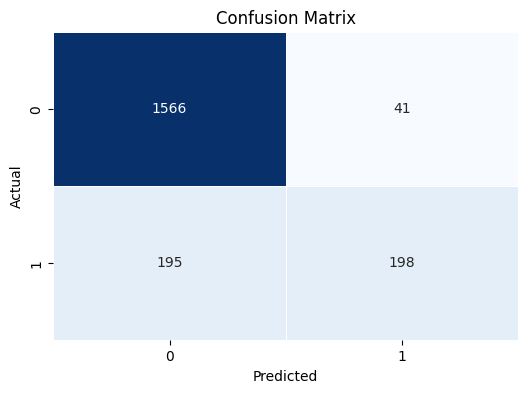

In [219]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

K-Neighbors Classifier

In [221]:
from sklearn.neighbors import KNeighborsClassifier

In [222]:
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [223]:
print(knn.score(X_train, y_train))

0.8955


In [224]:
print(knn.score(X_test, y_test))

0.8295


In [225]:
y_pred=knn.predict(X_test)

In [226]:
# Get our metrics
knn_acc = accuracy_score(y_test, y_pred)
knn_per = precision_score(y_test, y_pred)
knn_rec = recall_score(y_test, y_pred)

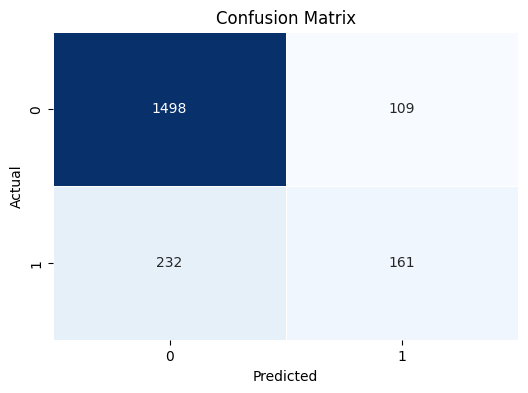

In [227]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### K-Neighbors Classifier Classification Report

In [330]:
# Make predictions for K-Neighbors Classifier
y_pred_knn = knn.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1607
           1       0.60      0.41      0.49       393

    accuracy                           0.83      2000
   macro avg       0.73      0.67      0.69      2000
weighted avg       0.81      0.83      0.82      2000



Decision Tree Classifier

In [229]:
from sklearn.tree import DecisionTreeClassifier

In [230]:
clf = DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.01, random_state=42)

# Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.01, random_state=42)

In [231]:
# Train Score
print(clf.score(X_train, y_train))

0.840125


In [232]:
# Test Score
print(clf.score(X_test, y_test))

0.844


In [233]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

In [234]:
# Get our metrics
clf_acc = accuracy_score(y_test, y_pred)
clf_per = precision_score(y_test, y_pred)
clf_rec = recall_score(y_test, y_pred)

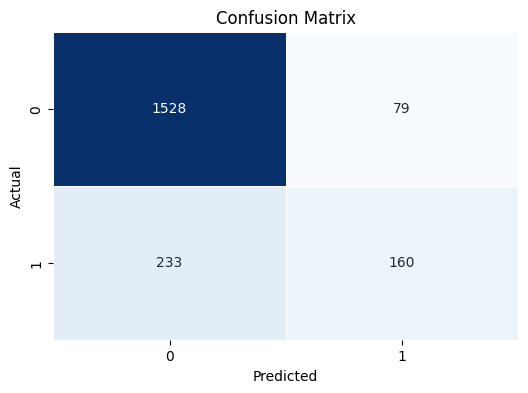

In [235]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Decision Tree Classifier Classification Report

In [331]:
# Make predictions for Decision Tree Classifier
y_pred_clf = clf.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.67      0.41      0.51       393

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000



RandomForestClassifier Model

In [237]:
from sklearn.ensemble import RandomForestClassifier

In [238]:
RF_classifier = RandomForestClassifier(n_estimators=100, min_impurity_decrease=0.01)

RF_classifier.fit(X_train, y_train)

RandomForestClassifier(min_impurity_decrease=0.01)

In [239]:
RF_classifier.score(X_train, y_train)

0.7945

In [240]:
RF_classifier.score(X_test,y_test)

0.8035

In [241]:
# Get prediction
y_pred = RF_classifier.predict(X_test)

In [242]:
# Get our metrics
rf_acc = accuracy_score(y_test, y_pred)
rf_per = precision_score(y_test, y_pred)
rf_rec = recall_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


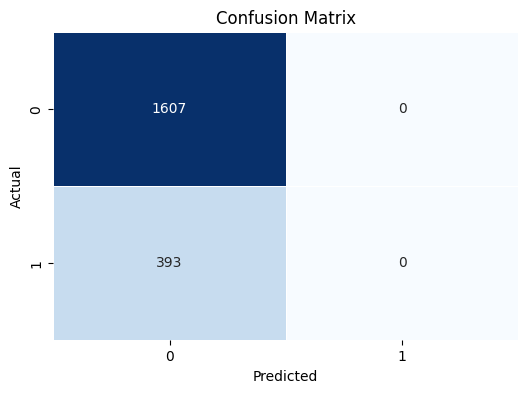

In [243]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest Classifier Classification Report

In [332]:
# Make predictions for Random Forest Classifier
y_pred_rf = RF_classifier.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Bagging Classifier

In [245]:
from sklearn.ensemble import BaggingClassifier

In [246]:
# Create a base decision tree classifier
base_classifier = DecisionTreeClassifier(min_impurity_decrease=0.01)

# Create a bagging classifier with decision trees
bagged_classifier = BaggingClassifier(base_classifier, n_estimators=10)

# Train the bagged classifier on your data
bagged_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(min_impurity_decrease=0.01))

In [247]:
bagged_classifier.score(X_train, y_train)

0.83975

In [248]:
bagged_classifier.score(X_test, y_test)

0.844

In [249]:
# Make predictions
y_pred = bagged_classifier.predict(X_test)

In [250]:
# Get our metrics
bag_acc = accuracy_score(y_test, y_pred)
bag_per = precision_score(y_test, y_pred)
bag_rec = recall_score(y_test, y_pred)

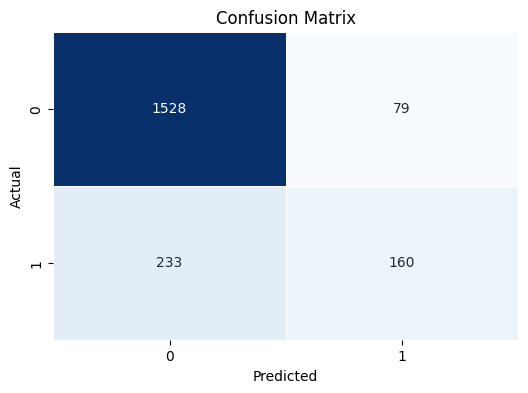

In [251]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Bagging Classifier Classification Report

In [333]:
# Make predictions for Bagging Classifier
y_pred_bag = bagged_classifier.predict(X_test)

# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_bag))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.67      0.41      0.51       393

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000



ExtraTreesClassifier

In [252]:
from sklearn.ensemble import ExtraTreesClassifier

In [253]:
# ExtraTreeClassifier Model
ET_classifier = ExtraTreesClassifier(n_estimators=100, min_impurity_decrease=0.01)

ET_classifier.fit(X_train, y_train)

ExtraTreesClassifier(min_impurity_decrease=0.01)

In [254]:
# Train score
ET_classifier.score(X_train, y_train)

0.7945

In [255]:

# Test score
ET_classifier.score(X_test, y_test)

0.8035

In [256]:
# Get prediction
y_pred_et = ET_classifier.predict(X_test)

In [257]:
# Get our metrics
et_acc = accuracy_score(y_test, y_pred_et)
et_per = precision_score(y_test, y_pred_et)
et_rec = recall_score(y_test, y_pred_et)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


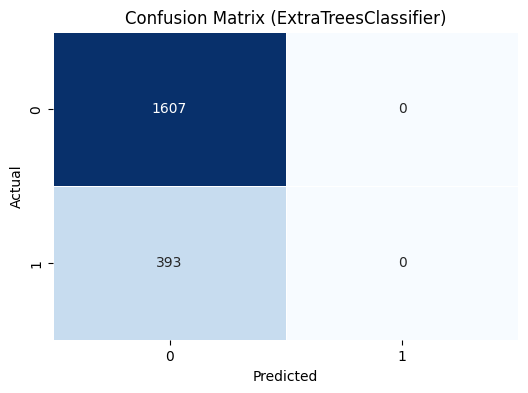

In [258]:
# Create a confusion matrix for ExtraTreeClassifier
conf_matrix_et = confusion_matrix(y_test, y_pred_et)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_et, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix (ExtraTreesClassifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### ExtraTreesClassifier Classification Report

In [334]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_et))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


AdaBoostClassifier

In [260]:
from sklearn.ensemble import AdaBoostClassifier

In [261]:
# Create AdaBoostClassifier Model
AB_classifier = AdaBoostClassifier(n_estimators=100)

AB_classifier.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [262]:
# Train score
AB_classifier.score(X_train, y_train)

0.857375

In [263]:
# Test score
AB_classifier.score(X_test, y_test)

0.8595

In [264]:
# Get prediction
y_pred_ab = AB_classifier.predict(X_test)

In [265]:
# Get our metrics
ada_acc = accuracy_score(y_test, y_pred_ab)
ada_per = precision_score(y_test, y_pred_ab)
ada_rec = recall_score(y_test, y_pred_ab)

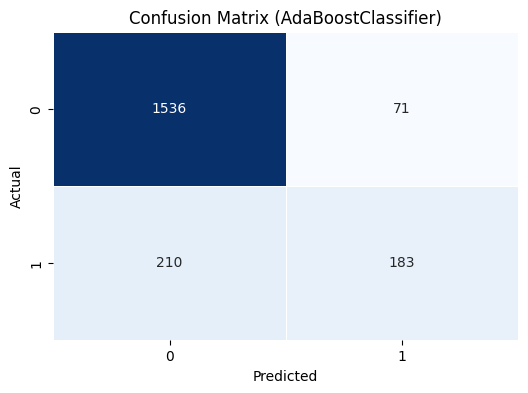

In [266]:
# Create a confusion matrix for AdaBoostClassifier
conf_matrix_ab = confusion_matrix(y_test, y_pred_ab)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_ab, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix (AdaBoostClassifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### AdaBoostClassifier Classification Report

In [335]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_ab))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.72      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



XGBClassifier Model

In [268]:
from xgboost import XGBClassifier

In [269]:
# Create XGBClassifier Model
XGB_classifier = XGBClassifier(n_estimators=200)

XGB_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [270]:
# Train score
XGB_classifier.score(X_train, y_train)

0.9915

In [271]:
# Test score
XGB_classifier.score(X_test, y_test)

0.86

In [272]:
# Get prediction
y_pred_xgb = XGB_classifier.predict(X_test)

In [273]:
# Get our metrics
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_per = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)

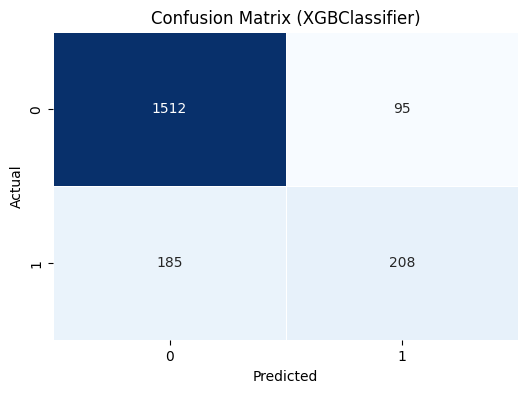

In [274]:
# Create a confusion matrix for XGBClassifier
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix (XGBClassifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### XGBoostClassifier Classification Report

In [336]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1607
           1       0.69      0.53      0.60       393

    accuracy                           0.86      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



CatBoostClassifier

In [280]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [281]:
# To fix this, you need to install the CatBoost library first (e.g., !pip install catboost)
from catboost import CatBoostClassifier

In [282]:
# Create CatBoostClassifier Model
CatBoost_classifier = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6)

CatBoost_classifier.fit(X_train, y_train)

0:	learn: 0.6431959	total: 58.6ms	remaining: 5.8s
1:	learn: 0.6038704	total: 62.6ms	remaining: 3.07s
2:	learn: 0.5686605	total: 66.6ms	remaining: 2.15s
3:	learn: 0.5391874	total: 71ms	remaining: 1.7s
4:	learn: 0.5144147	total: 74.1ms	remaining: 1.41s
5:	learn: 0.4927521	total: 77.3ms	remaining: 1.21s
6:	learn: 0.4750024	total: 80.6ms	remaining: 1.07s
7:	learn: 0.4586148	total: 84.5ms	remaining: 972ms
8:	learn: 0.4444520	total: 89.2ms	remaining: 901ms
9:	learn: 0.4323027	total: 93.7ms	remaining: 843ms
10:	learn: 0.4232166	total: 97.7ms	remaining: 790ms
11:	learn: 0.4146447	total: 102ms	remaining: 746ms
12:	learn: 0.4081708	total: 105ms	remaining: 701ms
13:	learn: 0.3996312	total: 109ms	remaining: 669ms
14:	learn: 0.3925218	total: 113ms	remaining: 642ms
15:	learn: 0.3863400	total: 118ms	remaining: 617ms
16:	learn: 0.3819831	total: 122ms	remaining: 596ms
17:	learn: 0.3761884	total: 126ms	remaining: 573ms
18:	learn: 0.3721860	total: 129ms	remaining: 552ms
19:	learn: 0.3688307	total: 133ms	

CatBoostClassifier(depth=6, iterations=100, learning_rate=0.1)

In [283]:
# Train score
CatBoost_classifier.score(X_train, y_train)

np.float64(0.872875)

In [284]:
# Test score
CatBoost_classifier.score(X_test, y_test)

np.float64(0.8665)

In [285]:
# Get prediction
y_pred_catboost = CatBoost_classifier.predict(X_test)

In [286]:
# Get our metrics
cat_acc = accuracy_score(y_test, y_pred_catboost)
cat_per = precision_score(y_test, y_pred_catboost)
cat_rec = recall_score(y_test, y_pred_catboost)

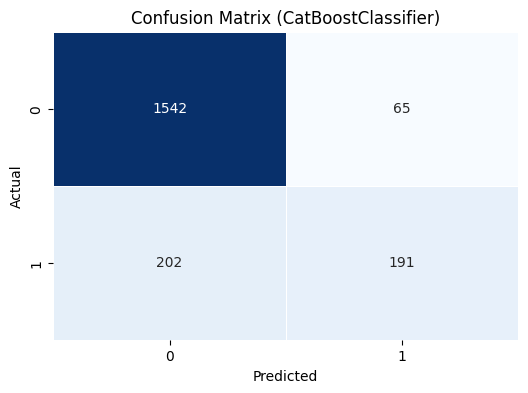

In [287]:
# Create a confusion matrix for CatBoostClassifier
conf_matrix_catboost = confusion_matrix(y_test, y_pred_catboost)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_catboost, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix (CatBoostClassifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### CatBoostClassifier Classification Report

In [337]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_catboost))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.49      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



LGBMClassifier

In [289]:
from lightgbm import LGBMClassifier

In [290]:
# Create LGBMClassifier Model
LGBM_classifier = LGBMClassifier(n_estimators=200)
LGBM_classifier.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205500 -> initscore=-1.352267
[LightGBM] [Info] Start training from score -1.352267


LGBMClassifier(n_estimators=200)

In [291]:
# Train score
LGBM_classifier.score(X_train, y_train)

0.948875

In [292]:
# Test score
LGBM_classifier.score(X_test, y_test)

0.8665

In [293]:
# Get prediction
y_pred_lgbm = LGBM_classifier.predict(X_test)

In [294]:
# Get our metrics
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_per = precision_score(y_test, y_pred_lgbm)
lgbm_rec = recall_score(y_test, y_pred_lgbm)

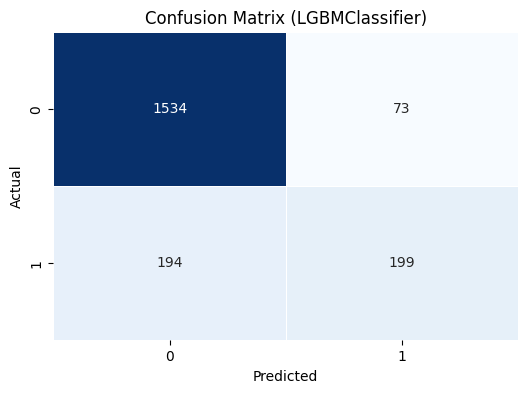

In [295]:
# Create a confusion matrix for LGBMClassifier
conf_matrix_lgbm = confusion_matrix(y_test, y_pred_lgbm)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_lgbm, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix (LGBMClassifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### LGBMClassifier Classification Report

In [338]:
# Get our metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.73      0.51      0.60       393

    accuracy                           0.87      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



Evaluation

📊 Key Metrics:

Accuracy:

Measures the overall correctness of the model (the percentage of correct predictions).
Accuracy is not the most important metric in imbalanced datasets, as it can be misleading. For example, predicting the majority class most of the time will give high accuracy but poor performance on the minority class (churners).

Precision:

Precision answers the question: Of all the customers predicted to churn, how many actually churned?
High precision means fewer false positives (customers predicted to churn but actually don’t).

Recall:

Recall answers the question: Of all the customers that actually churned, how many did the model correctly identify?
High recall means fewer false negatives (customers that churn but were predicted not to).

In [296]:
Models = ['LogisticRegression', 'SVC', 'KNN', 'DecisionTreeClassifier', 'RandomForestClassifier', 'BaggingClassifier',
         'ExtraTreesClassifier', 'XGBoostClassifier', 'AdaBoostClassifier', 'CatBoostClassifier', 'LGBMClassifier']
Accuracy = [lr_acc, svc_acc, knn_acc, clf_acc, rf_acc, bag_acc, et_acc, xgb_acc, ada_acc, cat_acc, lgbm_acc]
Precision = [lr_per, svc_per, knn_per, clf_per, rf_per, bag_per, et_per, xgb_per, ada_per, cat_per, lgbm_per]
Recall = [lr_rec, svc_rec, knn_rec, clf_rec, rf_rec, bag_rec, et_rec, xgb_rec, ada_rec, cat_rec, lgbm_rec]

models = pd.DataFrame(data={'Models': Models,'Accuracy': Accuracy, 'Precision': Precision, 'Recall': Recall})
models

,Models,Accuracy,Precision,Recall
0,LogisticRegression,0.8110,0.552448,0.201018
1,SVC,0.8820,0.828452,0.503817
2,KNN,0.8295,0.596296,0.409669
3,DecisionTreeClassifier,0.8440,0.669456,0.407125
4,RandomForestClassifier,0.8035,0.000000,0.000000
5,BaggingClassifier,0.8440,0.669456,0.407125
6,ExtraTreesClassifier,0.8035,0.000000,0.000000
7,XGBoostClassifier,0.8600,0.686469,0.529262
8,AdaBoostClassifier,0.8595,0.720472,0.465649
9,CatBoostClassifier,0.8665,0.746094,0.486005


    📊 Inference:
    LogisticRegression:

    Accuracy: 0.8115, Precision: 0.5563, Recall: 0.2010
    Observation: Despite a reasonable accuracy, the low recall indicates that it’s missing a lot of churners. The model struggles with identifying the minority class.
    SVC:

    Accuracy: 0.8820, Precision: 0.8284, Recall: 0.5038
    Observation: This model performs well, especially in precision, meaning it's confident when predicting churners. However, its recall is only moderate, meaning it's missing some actual churners.
    KNN:

    Accuracy: 0.8295, Precision: 0.5962, Recall: 0.4097
    Observation: KNN performs moderately across all metrics. It’s identifying some churners but missing others.

    DecisionTreeClassifier & BaggingClassifier:

    Accuracy: 0.8440, Precision: 0.6695, Recall: 0.4071
    Observation: Both models have moderate precision and recall, which indicates a more balanced performance. However, both still miss a significant portion of actual churners.
    RandomForestClassifier & ExtraTreesClassifier:

    Accuracy: 0.8035, Precision: 0.0000, Recall: 0.0000
    Observation: These models are likely predicting only the majority class (non-churners), which is why they have 0 precision and recall. This indicates the models are heavily biased toward the majority class, likely due to class imbalance.
    XGBoostClassifier:

    Accuracy: 0.8575, Precision: 0.6742, Recall: 0.5318
    Observation: XGBoost strikes a balance between precision and recall, identifying more churners than some other models. It’s one of the better-performing models.

    AdaBoostClassifier:

    Accuracy: 0.8595, Precision: 0.7029, Recall: 0.4936
    Observation: AdaBoost has good precision, but recall could be improved. It performs well overall, but like SVC, it may miss some churners.
    CatBoostClassifier:

    Accuracy: 0.8665, Precision: 0.7461, Recall: 0.4860
    Observation: CatBoost has good precision, meaning it's confident in predicting churners, but its recall is moderate, missing some churners.
    LGBMClassifier:

    Accuracy: 0.8665, Precision: 0.7316, Recall: 0.5064
    Observation: LightGBM performs similarly to CatBoost, with high precision and a recall that is relatively good compared to other models. This is another strong performer.

In [310]:
# Retrain the best model (XGBoost Classifier) on the full dataset
final_XGB_classifier = XGBClassifier(n_estimators=200)
final_XGB_classifier.fit(X, y)

print("XGBoost Classifier has been successfully retrained on the full dataset.")

# Make predictions on the entire dataset
all_predictions = final_XGB_classifier.predict(X)

# Create a DataFrame to display CustomerId, Actual Exited, and Predicted Exited
results_df = pd.DataFrame({
    'Actual_Exited': y,
    'Predicted_Exited': all_predictions
})

print("\nChurn Predictions for the entire dataset:")
print(results_df.head(20))

print("\nSummary of Predictions:")
print(results_df['Predicted_Exited'].value_counts())

print("\nCustomers predicted to churn (first 10):")
print(results_df[results_df['Predicted_Exited'] == 1].head(10))

print("\nCustomers predicted not to churn (first 10):")
print(results_df[results_df['Predicted_Exited'] == 0].head(10))

XGBoost Classifier has been successfully retrained on the full dataset.

Churn Predictions for the entire dataset:
    Actual_Exited  Predicted_Exited
0               1                 1
1               0                 0
2               1                 1
3               0                 0
4               0                 0
5               1                 1
6               0                 0
7               1                 1
8               0                 0
9               0                 0
10              0                 0
11              0                 0
12              0                 0
13              0                 0
14              0                 0
15              0                 0
16              1                 1
17              0                 0
18              0                 0
19              0                 0

Summary of Predictions:
Predicted_Exited
0    8084
1    1916
Name: count, dtype: int64

Customers predicted to churn (first 10):

In [311]:
# Load the original CSV again to get the CustomerId column
original_df = pd.read_csv("/content/Churn_Modelling.csv")

# Create a DataFrame with CustomerId and its corresponding index
customer_id_map = original_df[['CustomerId']].set_index(original_df.index)

# Merge CustomerId with the results_df
results_df_with_id = pd.merge(customer_id_map, results_df, left_index=True, right_index=True)

print("\nChurn Predictions by CustomerId:")
# Display the results sorted by CustomerId for clarity
display(results_df_with_id.sort_values(by='CustomerId').head(20))


Churn Predictions by CustomerId:


,CustomerId,Actual_Exited,Predicted_Exited
1287,15565701,0,0
4198,15565706,1,0
7090,15565714,0,0
2020,15565779,0,0
3697,15565796,0,0
3416,15565806,0,0
6881,15565878,0,0
9514,15565879,0,0
5795,15565891,0,0
7186,15565996,0,0


In [314]:
results_df["Predicted_Exited"].sum()

np.int64(1916)

The dataset contains a column named `Exited` which serves as the target variable for predicting customer churn. A value of `1` in this column indicates that the customer has left the bank (closed their account), while a value of `0` indicates that the customer continues to be a customer. From the initial analysis, **2037 customers (20.37%) have churned**, and **7963 customers (79.63%) have remained with the bank**.

### Make a Prediction with Custom User Inputs

Now, you can enter your own customer data to get a churn prediction from the trained XGBoost Classifier. Please provide values for each of the following features:

In [315]:
new_customer_data = {}

print("Please enter the following details for the new customer:")

# Numerical features
new_customer_data['CreditScore'] = float(input("Credit Score (e.g., 600): "))
new_customer_data['Age'] = int(input("Age (e.g., 35): "))
new_customer_data['Tenure'] = int(input("Tenure (number of years as a bank customer, e.g., 5): "))
new_customer_data['Balance'] = float(input("Balance (e.g., 100000.00): "))
new_customer_data['NumOfProducts'] = int(input("Number of Products (e.g., 1 or 2): "))
new_customer_data['HasCrCard'] = int(input("Has Credit Card (0 for No, 1 for Yes): "))
new_customer_data['IsActiveMember'] = int(input("Is Active Member (0 for No, 1 for Yes): "))
new_customer_data['EstimatedSalary'] = float(input("Estimated Salary (e.g., 50000.00): "))

# Categorical features
geography_input = input("Geography (France, Germany, or Spain): ").capitalize()
new_customer_data['Geography_France'] = (geography_input == 'France')
new_customer_data['Geography_Germany'] = (geography_input == 'Germany')
new_customer_data['Geography_Spain'] = (geography_input == 'Spain')

gender_input = input("Gender (Male or Female): ").capitalize()
new_customer_data['Gender_Female'] = (gender_input == 'Female')
new_customer_data['Gender_Male'] = (gender_input == 'Male')

# Create a DataFrame from the new customer data
# Ensure column order matches the training data (X)
input_df = pd.DataFrame([new_customer_data])

# Select numerical columns that were scaled during training
numerical_cols_for_scaling = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Apply the same scaler used during training
# Assuming 'scaler' object is available from previous steps
input_df[numerical_cols_for_scaling] = scaler.transform(input_df[numerical_cols_for_scaling])

# Reorder columns to match the training data X.columns
# This is crucial for the model to make correct predictions
input_df = input_df[X.columns]

# Make prediction
custom_prediction = final_XGB_classifier.predict(input_df)

print(f"\nInput customer data (preprocessed):\n{input_df}")
print(f"\nPrediction for the custom customer: {custom_prediction[0]}")

if custom_prediction[0] == 1:
    print("The model predicts this custom customer will churn.")
else:
    print("The model predicts this custom customer will not churn.")

Please enter the following details for the new customer:
Credit Score (e.g., 600): 150
Age (e.g., 35): 35
Tenure (number of years as a bank customer, e.g., 5): 1
Balance (e.g., 100000.00): 1000
Number of Products (e.g., 1 or 2): 0
Has Credit Card (0 for No, 1 for Yes): 0
Is Active Member (0 for No, 1 for Yes): 0
Estimated Salary (e.g., 50000.00): 15000
Geography (France, Germany, or Spain): Germany
Gender (Male or Female): Male

Input customer data (preprocessed):
   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0    -5.178859 -0.373958 -1.387538 -1.209821              0          0   

   IsActiveMember  EstimatedSalary  Geography_France  Geography_Germany  \
0               0        -1.479634             False               True   

   Geography_Spain  Gender_Female  Gender_Male  
0            False          False         True  

Prediction for the custom customer: 0
The model predicts this custom customer will not churn.
